In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
from jubilee_controller import JubileeMotionController
import matplotlib.pyplot as plt
import lgpio
import time
import numpy as np 
from pynput import keyboard
import cv2
from datetime import datetime
from email_sender import send_email
from image_processing import detect_circle

In [3]:
jubilee = JubileeMotionController()

In [4]:
jubilee.home_all(mesh_mode_z=False)
jubilee.protect_tools(on=True)
jubilee.move_xyz_absolute(z=50)

In [6]:

class Polidor:
    """
    Controle de motor DC usando ponte H L298N.
    Compatível com Raspberry Pi 5 usando lgpio.
    """

    def __init__(self,machine,parking_position_xy,move_velocity=1000, pwm_pin=12, in1_pin=20, in2_pin=21):
        """
        Args:
            pwm_pin (int): GPIO PWM (ENA)
            in1_pin (int): GPIO direção IN1
            in2_pin (int): GPIO direção IN2
            pwm_freq (int): frequência PWM em Hz
        """
        self.name = "Polidor"
        self.parking_position_x, self.parking_position_y = parking_position_xy
        self.machine = machine
        self.move_velocity = move_velocity
        self.installed = False

        self.pwm_pin = pwm_pin
        self.in1_pin = in1_pin
        self.in2_pin = in2_pin

        self.handle = None

    def install(self):
        """
        Instala o polidor na máquina Jubilee.

        Move o cabeçote até as coordenadas específicas necessárias
        para acoplar o polidor ao sistema.
        """
    
        if self.machine.tool is None:     

            if self.machine.position[2] < 140:
                self.machine.move_xyz_absolute(z=140)
            self.machine.protect_tools(on=False)

            self.machine.move_xyz_absolute(y=220, velocity=self.move_velocity)
            self.machine.move_xyz_absolute(x=self.parking_position_x, velocity=self.move_velocity)
            self.machine.gcode("G91 G1 U10 F600 G90")  
            self.machine.gcode("G91 G1 H1 U300 F3000 G90")  
            self.machine.move_xyz_absolute(y=self.parking_position_y, velocity=self.move_velocity)
            self.machine.gcode("G92 U20")  
            self.machine.gcode("G91 G1 U-10 F600 G90")  
            self.machine.gcode("G91 G1 H1 U-300 F3000 G90")
            self.machine.gcode("G92 U0") 
            self.machine.move_xyz_absolute(y=70, velocity=self.move_velocity)

            if self.machine.mode_protect_tools:
                self.machine.protect_tools(on=True,min_xy=[20,90])
                self.machine.gcode("M208 Z140:320")
                

            self.machine.tool = self.name
            self.installed = True

        else:
            print(f"[{self.name}] Não é possível instalar: desinstale '{self.machine.tool}' primeiro.")


    def uninstall(self, velocity=None):
        """
        Desinstala o polidor da máquina Jubilee.

        Move o cabeçote até as coordenadas específicas necessárias
        para desacoplar o polidor do sistema.
        """

        if self.machine.tool == self.name:
            v = velocity or self.move_velocity
            self.machine.protect_tools(on=False)

            self.machine.move_xyz_absolute(y=90, velocity=v)
            self.machine.move_xyz_absolute(x=self.parking_position_x, velocity=v)
            self.machine.move_xyz_absolute(y=self.parking_position_y, velocity=v)
            self.machine.gcode("G91 G1 U10 F600 G90")  
            self.machine.gcode("G91 G1 H1 U300 F3000 G90")
            self.machine.move_xyz_relative(y=12, velocity=v)
            self.machine.move_xyz_absolute(y=70, velocity=self.move_velocity)
            self.machine.move_xyz_absolute(x=50, y=120, velocity=self.move_velocity)
            self.machine.gcode("G92 U20")  
            self.machine.gcode("G91 G1 U-10 F600 G90")  
            self.machine.gcode("G91 G1 H1 U-300 F3000 G90")
            self.machine.gcode("G92 U0") 

            if self.machine.mode_protect_tools:
                self.machine.protect_tools(on=True)

            self.machine.tool = None
            self.installed = False
            self.machine.gcode("M208 Z0:320")

        else:
            print(f"[{self.name}] Nenhum polidor instalada ou outra ferramenta ativa.")

    def begin(self):
        """Inicializa GPIO."""

        self.handle = lgpio.gpiochip_open(0)

        lgpio.gpio_claim_output(self.handle, self.in1_pin)
        lgpio.gpio_claim_output(self.handle, self.in2_pin)
        lgpio.gpio_claim_output(self.handle, self.pwm_pin)

        self.stop()

    def end(self):
        """Fecha GPIO."""

        if self.handle is not None:

            self.stop()

            lgpio.gpiochip_close(self.handle)
            self.handle = None
            
    def forward(self):

        lgpio.gpio_write(self.handle, self.in1_pin, 1)
        lgpio.gpio_write(self.handle, self.in2_pin, 0)


    def backward(self):

        lgpio.gpio_write(self.handle, self.in1_pin, 0)
        lgpio.gpio_write(self.handle, self.in2_pin, 1)


    def stop(self):

        lgpio.gpio_write(self.handle, self.in1_pin, 0)
        lgpio.gpio_write(self.handle, self.in2_pin, 0)



In [7]:
motor = Polidor(
    machine=jubilee,
    parking_position_xy=(44,20),
    pwm_pin=12,
    in1_pin=20,
    in2_pin=21
)



In [38]:
motor.uninstall()
#motor.install()

In [9]:
motor.begin()

In [33]:
motor.forward()

In [34]:
motor.stop()

In [12]:
motor.install()

In [26]:
posicoes =[[67,194,165],[127,194,165],[127,254,165],[67,254,165]]

In [ ]:
jubilee.move_xyz_absolute(65, 192, 165, velocity=3000)

In [37]:
#forma matriz 10 por 10
n_movimentacoes_x = 3
n_movimentacoes_y = 3

for i in range(4):
    jubilee.move_xyz_absolute(z=165, velocity=3000)
    jubilee.move_xyz_absolute(x=posicoes[i][0], y=posicoes[i][1], velocity=3000)
    jubilee.move_xyz_absolute(z=143, velocity=3000)
    time.sleep(4)
    motor.backward()
    jubilee.move_xyz_absolute(z=137.5, velocity=3000)
    time.sleep(15)
    motor.stop()
    time.sleep(1)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


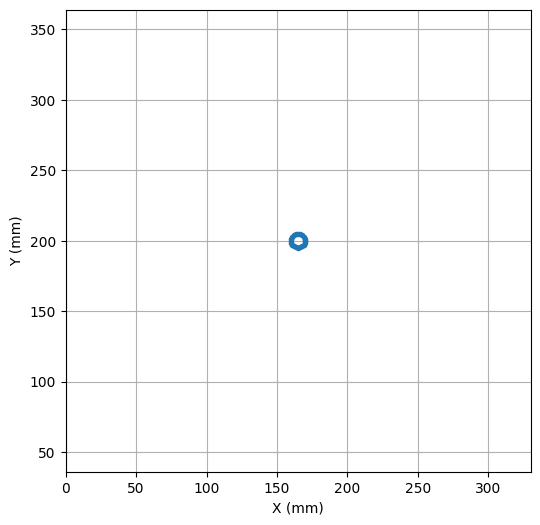

In [39]:
xc = 165
yc = 200
R = 5  
z = 200
velocidade = 10000
for k in range(1):
    n_pontos = 20

    for i in range(n_pontos + 1):
        theta = 2 * np.pi * i / n_pontos
        x = xc + R * np.cos(theta)
        y = yc + R * np.sin(theta)
        jubilee.move_xyz_absolute(x=x, y=y, z=z, velocity=velocidade)

    theta = np.linspace(0, 2 * np.pi, n_pontos + 1)
    x = xc + R * np.cos(theta)
    y = yc + R * np.sin(theta)

    plt.figure(figsize=(6, 6))
    plt.plot(x, y, '-o', markersize=3)
    plt.xlabel("X (mm)")
    plt.ylabel("Y (mm)")
    plt.axis("equal")
    plt.xlim((0,330))
    plt.ylim((0,400))
    plt.grid(True)
    plt.show()


In [40]:
motor.uninstall()